# Treinamento com Transfer Learning (ResNet18) — Grupo 4

Notebook executado no Google Colab (GPU T4) para treinar o modelo de classificação de imagens astronômicas com transfer learning.

**Resultado obtido:** 55,81% de acurácia no conjunto de teste (6 classes).

Este notebook complementa o código-fonte principal em `src/`, que também oferece uma versão de CNN treinada do zero (`--model scratch`), utilizável sem GPU.

In [1]:
import torch
print("GPU disponível:", torch.cuda.is_available())
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU disponível: True
Dispositivo: Tesla T4


In [2]:
!pip install -q scikit-learn matplotlib pillow

In [3]:
from google.colab import files

print("Selecione o arquivo .zip baixado do Kaggle (space-images-category)")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
!unzip -q "{zip_name}" -d raw_dataset
!find raw_dataset -maxdepth 2 -type d

Selecione o arquivo .zip baixado do Kaggle (space-images-category)


Saving archive.zip to archive.zip
raw_dataset
raw_dataset/space images
raw_dataset/space images/cosmos space - Google Search
raw_dataset/space images/constellation - Google Search
raw_dataset/space images/nebula - Google Search
raw_dataset/space images/planets - Google Search
raw_dataset/space images/stars - Google Search
raw_dataset/space images/galaxies - Google Search


In [4]:
import os, random, shutil

random.seed(42)

# Ajuste esse caminho se a pasta extraída tiver outro nome (confira a saída da célula anterior)
RAW_DIR = "raw_dataset/space images"
OUT_DIR = "data"

FOLDER_MAPPING = {
    "constellation - Google Search": "constellations",
    "cosmos space - Google Search": "cosmos",
    "galaxies - Google Search": "galaxies",
    "nebula - Google Search": "nebulae",
    "planets - Google Search": "planets",
    "stars - Google Search": "stars",
}

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15

for folder_name in os.listdir(RAW_DIR):
    folder_path = os.path.join(RAW_DIR, folder_name)
    if not os.path.isdir(folder_path):
        continue

    class_name = FOLDER_MAPPING.get(folder_name, folder_name.lower().strip())
    files_list = [f for f in os.listdir(folder_path) if os.path.splitext(f)[1].lower() in VALID_EXTS]
    random.shuffle(files_list)

    n = len(files_list)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    splits = {
        "train": files_list[:n_train],
        "val": files_list[n_train:n_train + n_val],
        "test": files_list[n_train + n_val:],
    }

    for split, flist in splits.items():
        out_class_dir = os.path.join(OUT_DIR, split, class_name)
        os.makedirs(out_class_dir, exist_ok=True)
        for i, f in enumerate(flist):
            ext = os.path.splitext(f)[1].lower()
            shutil.copy(os.path.join(folder_path, f), os.path.join(out_class_dir, f"{class_name}_{i:04d}{ext}"))

    print(f"{class_name}: train={len(splits['train'])} val={len(splits['val'])} test={len(splits['test'])}")

cosmos: train=116 val=24 test=26
constellations: train=128 val=27 test=28
nebulae: train=118 val=25 test=27
planets: train=123 val=26 test=27
stars: train=122 val=26 test=27
galaxies: train=165 val=35 test=37


In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMG_SIZE = 128
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder("data/train", transform=train_transform)
val_dataset = datasets.ImageFolder("data/val", transform=eval_transform)
test_dataset = datasets.ImageFolder("data/test", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Treino:", len(train_dataset), "| Validação:", len(val_dataset), "| Teste:", len(test_dataset))

Classes: ['constellations', 'cosmos', 'galaxies', 'nebulae', 'planets', 'stars']
Treino: 772 | Validação: 163 | Teste: 172


In [6]:
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

# Congela o backbone pré-treinado
for param in model.parameters():
    param.requires_grad = False

# Substitui a camada final para as 6 classes do problema
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

print(model.fc)

Usando: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


Linear(in_features=512, out_features=6, bias=True)


In [7]:
import time
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    running_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train_mode)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if train_mode:
            optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        if train_mode:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

EPOCHS = 15
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

start = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE,
            "val_acc": val_acc,
        }, "best_model_transfer.pt")

print(f"\nTreinamento concluído em {(time.time()-start)/60:.1f} min. Melhor acurácia de validação: {best_val_acc:.4f}")

Epoch 01/15 | train_loss=1.7312 train_acc=0.3005 | val_loss=1.5131 val_acc=0.3865


Epoch 02/15 | train_loss=1.4073 train_acc=0.4573 | val_loss=1.3398 val_acc=0.4785


Epoch 03/15 | train_loss=1.2112 train_acc=0.5402 | val_loss=1.2927 val_acc=0.4908


Epoch 04/15 | train_loss=1.1677 train_acc=0.5674 | val_loss=1.2198 val_acc=0.5399


Epoch 05/15 | train_loss=1.1065 train_acc=0.5907 | val_loss=1.2032 val_acc=0.5706


...

Epoch 11/15 | train_loss=0.9528 train_acc=0.6373 | val_loss=1.1757 val_acc=0.5706


Epoch 12/15 | train_loss=0.8999 train_acc=0.6775 | val_loss=1.1581 val_acc=0.5767


Epoch 13/15 | train_loss=0.9045 train_acc=0.6762 | val_loss=1.1838 val_acc=0.5828


Epoch 14/15 | train_loss=0.9052 train_acc=0.6710 | val_loss=1.1707 val_acc=0.5583


Epoch 15/15 | train_loss=0.8550 train_acc=0.6554 | val_loss=1.1341 val_acc=0.5706

Treinamento concluído em 6.4 min. Melhor acurácia de validação: 0.5828


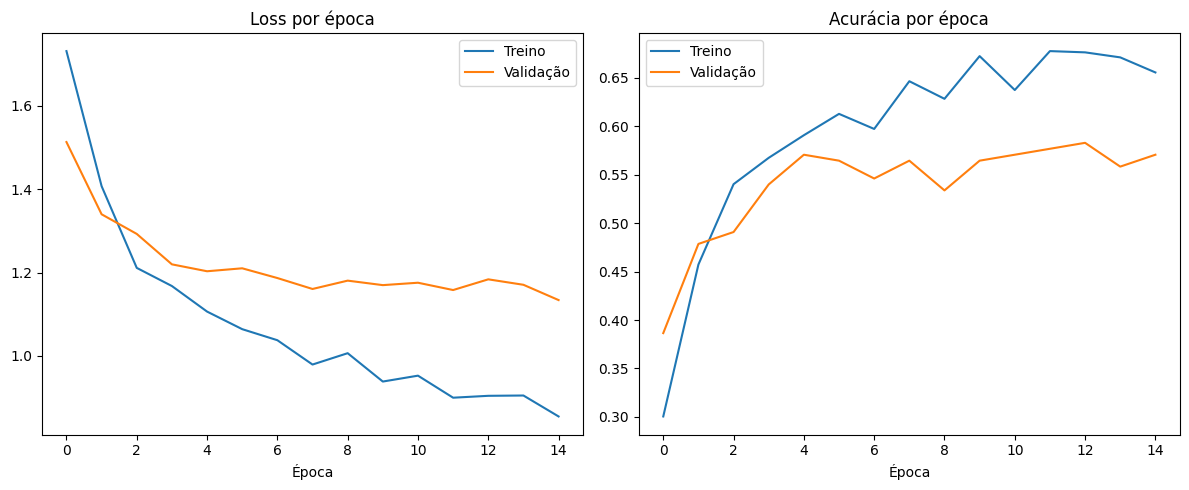

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history["train_loss"], label="Treino")
axes[0].plot(history["val_loss"], label="Validação")
axes[0].set_title("Loss por época"); axes[0].set_xlabel("Época"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Treino")
axes[1].plot(history["val_acc"], label="Validação")
axes[1].set_title("Acurácia por época"); axes[1].set_xlabel("Época"); axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves_transfer.png", dpi=150)
plt.show()

                precision    recall  f1-score   support

constellations     0.6875    0.7857    0.7333        28
        cosmos     0.6667    0.1538    0.2500        26
      galaxies     0.5806    0.4865    0.5294        37
       nebulae     0.4043    0.7037    0.5135        27
       planets     0.8462    0.8148    0.8302        27
         stars     0.3667    0.4074    0.3860        27

      accuracy                         0.5581       172
     macro avg     0.5920    0.5587    0.5404       172
  weighted avg     0.5914    0.5581    0.5426       172



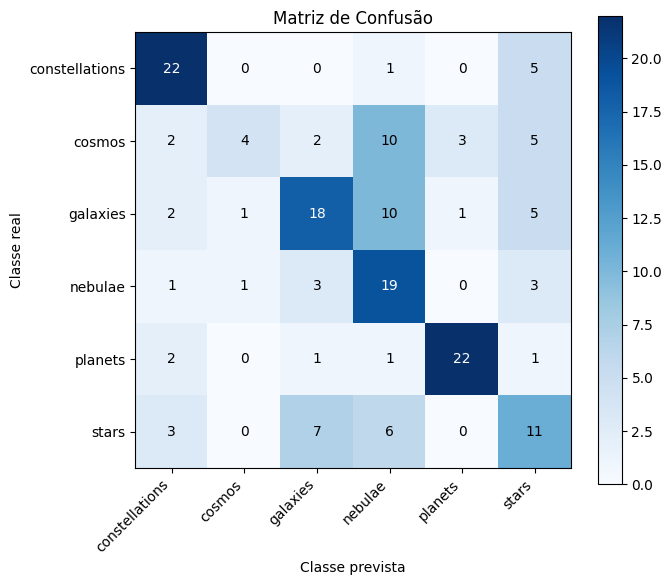


Acurácia final no teste: 0.5581


In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

checkpoint = torch.load("best_model_transfer.pt")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)
with open("classification_report_transfer.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
ax.set_xlabel("Classe prevista"); ax.set_ylabel("Classe real"); ax.set_title("Matriz de Confusão")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix_transfer.png", dpi=150)
plt.show()

accuracy = (all_preds == all_labels).mean()
print(f"\nAcurácia final no teste: {accuracy:.4f}")

In [10]:
from google.colab import files

!zip -r resultados_transfer.zip best_model_transfer.pt training_curves_transfer.png confusion_matrix_transfer.png classification_report_transfer.txt
files.download("resultados_transfer.zip")

  adding: best_model_transfer.pt (deflated 7%)
  adding: training_curves_transfer.png (deflated 8%)
  adding: confusion_matrix_transfer.png (deflated 13%)
  adding: classification_report_transfer.txt (deflated 59%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>